# Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**


 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

## Objective

The objective of this project is to understand how sequence models learn language patterns and generate meaningful text.

The project compares three different recurrent neural network architectures:

- Vanilla RNN
- LSTM
- GRU

Each model is trained on the same text corpus so that their learning behaviour and generated text can be compared fairly.

## 1. Import Libraries

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## 2. Preparing the Text Corpus

A text corpus is the collection of sentences from which the models learn grammar, sentence structure, and word relationships.

Instead of using the default sample text, a custom paragraph is used for training.

In [12]:
corpus = '''
artificial intelligence is changing the way people solve real world problems
deep learning helps computers learn patterns from large amounts of data
recurrent neural networks can understand sequential information in text
lstm models remember important information for a longer period of time
gru models provide faster training while maintaining good performance
text generation predicts the next word based on previous words in a sentence
natural language processing is widely used in chatbots and virtual assistants
machine learning models improve their performance through continuous training
choosing the right deep learning model depends on the problem and dataset
understanding sequence models helps build better language generation systems
'''

print(corpus)


artificial intelligence is changing the way people solve real world problems
deep learning helps computers learn patterns from large amounts of data
recurrent neural networks can understand sequential information in text
lstm models remember important information for a longer period of time
gru models provide faster training while maintaining good performance
text generation predicts the next word based on previous words in a sentence
natural language processing is widely used in chatbots and virtual assistants
machine learning models improve their performance through continuous training
choosing the right deep learning model depends on the problem and dataset
understanding sequence models helps build better language generation systems



## 3. Text Tokenization

The first step is to convert the text into numbers because deep learning models cannot understand words directly. Tokenization assigns a unique integer to every unique word in the text.

In [13]:
# Create tokenizer
tokenizer = Tokenizer()

# Learn the words from the corpus
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size :", total_words)

Vocabulary Size : 83


## 4. Creating Training Sequences

After tokenization, the text is converted into n-gram sequences. These sequences help the model learn the relationship between previous words and the next word. Since the sequences have different lengths, padding is used to make them the same size before preparing the training data.

In [14]:
training_sequences = []

# Create n-gram sequences
for sentence in corpus.split("\n"):

    current_sequence = tokenizer.texts_to_sequences([sentence])[0]

    for i in range(1, len(current_sequence)):

        sequence = current_sequence[:i + 1]
        training_sequences.append(sequence)

# Find maximum sequence length
sequence_length = max(len(seq) for seq in training_sequences)

# Pad shorter sequences
training_sequences = pad_sequences(
    training_sequences,
    maxlen=sequence_length,
    padding="pre"
)

# Prepare input and output
X = training_sequences[:, :-1]
y = training_sequences[:, -1]

print("Maximum Sequence Length :", sequence_length)
print("Total Training Sequences :", len(training_sequences))
print("Input Shape :", X.shape)
print("Output Shape :", y.shape)

Maximum Sequence Length : 13
Total Training Sequences : 95
Input Shape : (95, 12)
Output Shape : (95,)


# Model 1: Vanilla RNN

Vanilla RNN is the basic sequence model. 
It learns patterns from previous words to predict the next word. 
It works well for short sequences but may struggle to remember information over longer text.

In [15]:
rnn_model = Sequential()

rnn_model.add(Embedding(
    input_dim=total_words,
    output_dim=64,
    input_length=sequence_length-1
))

rnn_model.add(SimpleRNN(128))

rnn_model.add(Dense(total_words, activation="softmax"))

rnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

rnn_history = rnn_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.0000e+00 - loss: 4.4434 
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0526 - loss: 4.3467
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1053 - loss: 4.2660 
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1263 - loss: 4.1809
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1053 - loss: 4.1063
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1158 - loss: 4.0135 
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1579 - loss: 3.9206
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1579 - loss: 3.8113 
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2000 - loss: 3.6934 
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2842 - loss: 3.5877 
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3368 - loss: 3.4408 
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3368 

# Model 2: LSTM

LSTM is an improved version of RNN. It uses memory cells to remember important information for a longer time, making it better for learning long-term relationships between words.

In [16]:
lstm_model = Sequential()

lstm_model.add(Embedding(
    input_dim=total_words,
    output_dim=64,
    input_length=sequence_length-1
))

lstm_model.add(LSTM(128))

lstm_model.add(Dense(total_words, activation="softmax"))

lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_history = lstm_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.0526 - loss: 4.4184
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0526 - loss: 4.4069
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0526 - loss: 4.3929
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0526 - loss: 4.3727
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0526 - loss: 4.3294
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0421 - loss: 4.2621
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0421 - loss: 4.2336
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0526 - loss: 4.2027
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0737 - loss: 4.1591
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0316 - loss: 4.1367
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0737 - loss: 4.0998
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0737 - lo

# Model 3: GRU

GRU is another sequence model that is simpler than LSTM but still remembers useful information from previous words. It usually trains faster while giving performance similar to LSTM.

In [17]:
gru_model = Sequential()

gru_model.add(Embedding(
    input_dim=total_words,
    output_dim=64,
    input_length=sequence_length-1
))

gru_model.add(GRU(128))

gru_model.add(Dense(total_words, activation="softmax"))

gru_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

gru_history = gru_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.0105 - loss: 4.4201  
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0842 - loss: 4.4067
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0947 - loss: 4.3952
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0947 - loss: 4.3811
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0842 - loss: 4.3664 
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0737 - loss: 4.3423
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0421 - loss: 4.3086
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0421 - loss: 4.2502
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0421 - loss: 4.1745    
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0421 - loss: 4.1459
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0421 - loss: 4.0982    
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0

## Compare Training Loss

Training loss shows how the model improves during learning. A lower loss means the model is making better predictions. Comparing all three models helps understand which sequence model learns the text more effectively.

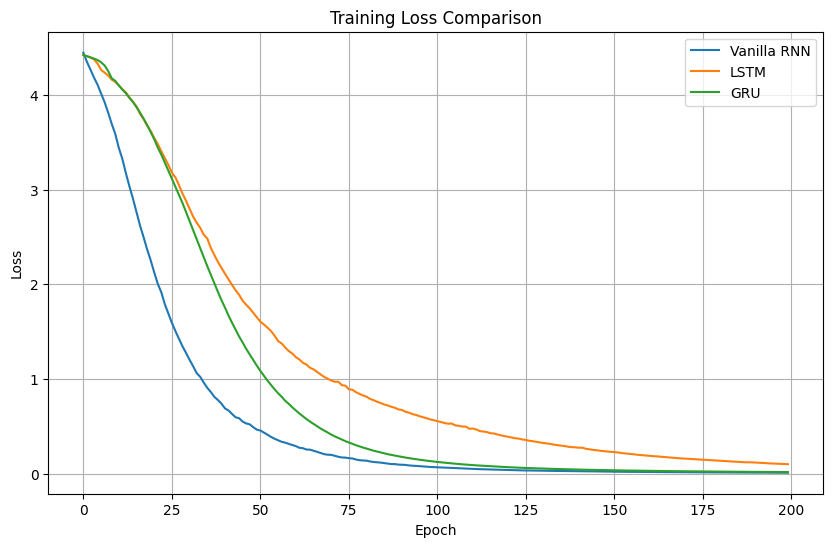

In [18]:
plt.figure(figsize=(10,6))

plt.plot(rnn_history.history["loss"],label="Vanilla RNN")
plt.plot(lstm_history.history["loss"],label="LSTM")
plt.plot(gru_history.history["loss"],label="GRU")
plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

#  Text Generation Function

After training, the models can predict the next word based on a given starting sentence. The word with the highest predicted probability is selected using `np.argmax()`. This process repeats until the required number of words is generated.

In [19]:
def generate_text(model, seed_text, next_words=10):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=sequence_length-1,
            padding="pre"
        )
        predicted = np.argmax(
            model.predict(token_list, verbose=0),
            axis=-1
        )[0]
        output_word = ""

        for word, index in tokenizer.word_index.items():

            if index == predicted:

                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

## Generate Text Samples

The same starting sentence is used for all three models. This makes it easier to compare how RNN, LSTM, and GRU generate text after learning from the training corpus.

In [20]:
seed = "artificial intelligence"

print("Vanilla RNN")
print(generate_text(rnn_model, seed, 10))

print("\nLSTM")
print(generate_text(lstm_model, seed, 10))

print("\nGRU")
print(generate_text(gru_model, seed, 10))

Vanilla RNN
artificial intelligence is changing the way people solve real world problems in

LSTM
artificial intelligence is changing the way people solve real world problems problems

GRU
artificial intelligence is changing the way people solve real world problems problems


## What I Learned

- Learned how text is converted into numbers using tokenization before training a deep learning model.
- Understood how n-gram sequences are created so the model can learn to predict the next word.
- Learned why padding is important to make all input sequences the same length.
- Built and compared three sequence models: Vanilla RNN, LSTM, and GRU.
- Understood that LSTM and GRU are better at remembering long-term patterns than a basic RNN.
- Learned how training loss helps compare the learning performance of different models.
- Implemented text generation using next-word prediction with `np.argmax()`.
- Gained practical experience in building a simple text generation system using TensorFlow and Keras.

## Final Conclusion

This project helped me understand how deep learning models can learn patterns from text and generate new sentences. Starting from text preprocessing and tokenization to building RNN, LSTM, and GRU models, each step gave practical experience in sequence modelling.

After comparing the three models, LSTM and GRU produced more meaningful text than the Vanilla RNN because they were able to capture long-term dependencies more effectively. Overall, this project strengthened my understanding of text generation and showed how different recurrent neural network architectures can be applied to natural language processing tasks.